In [1]:
import os
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_age_nk= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_nk

AnnData object with n_obs × n_vars = 207458 × 38606
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age (years)', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age i

In [4]:
adata_age_nk.obs['pica_cell_type_complete_01_gdT_corrected'].unique()
adata_age_nk.obs['pica_cell_type_complete_01_gdT_corrected'].value_counts()

pica_cell_type_complete_01_gdT_corrected
CD56_dim CD16+ NK           171221
ILC1                         16331
CD56_dim CD16+ KLRC2+ NK     15081
iILC2                         2400
nILC2                         1554
CD56_bright CD16- NK           871
Name: count, dtype: int64

In [5]:
adata_age_nk.obs["pica_id"].unique()
adata_age_nk.obs["pica_id"].value_counts()

pica_id
PICA0133    6111
PICA0011    5146
PICA0086    3212
PICA0020    3203
PICA0015    2988
            ... 
PICA0001     540
PICA0040     520
PICA0003     475
PICA0142     430
PICA0119     383
Name: count, Length: 128, dtype: int64

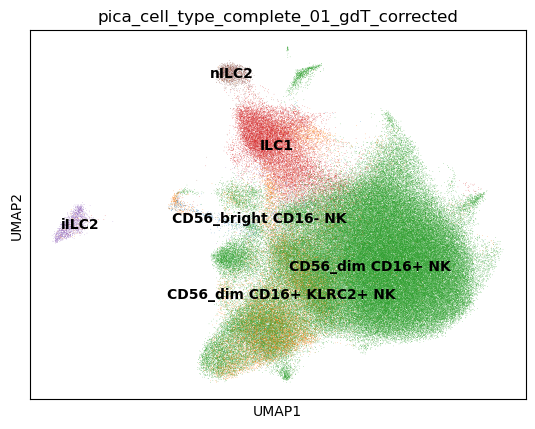

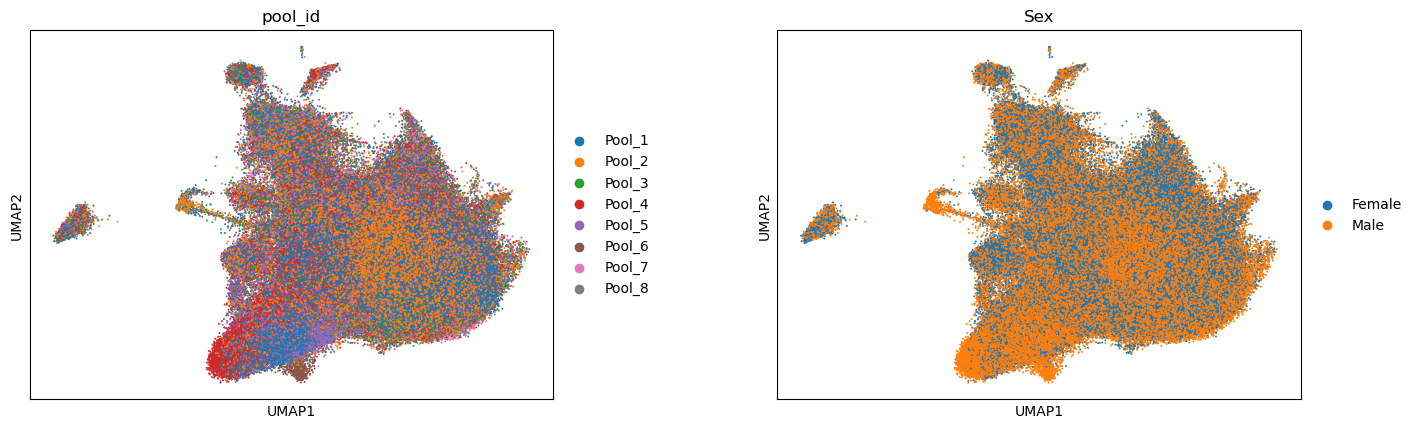

In [6]:
sc.pl.umap(adata_age_nk, color=["pica_cell_type_complete_01_gdT_corrected"], legend_loc="on data")
sc.pl.umap(adata_age_nk, color=["pool_id", "Sex"], wspace=0.3, size=8)

### Prepare for Milo analysis

In [7]:
adata_age_nk.obs['Batch'] = adata_age_nk.obs['sequencing_batch'].map(
        {
            '20240530_WGS_20240530_sc_PICA0001-PICA0007': "Batch01",
            '20240918_WGS_20240924_sc_PICA0008-PICA0032': "Batch02",
            '20241106_WGS_20241106_sc_PICA0033-PICA0069': "Batch03",
            '20250114_WGS_20241218_sc_PICA0071-PICA0097': "Batch04",
            '20250324_WGS_20250324_sc_PICA0098-PICA0118': "Batch05",
            '20250612_WGS_20250612_sc_PICA0119-PICA0146': "Batch06",
            '20250814_WGS_20250814_sc_PICA0147-PICA0173': "Batch07"
        }
    )

adata_age_nk.obs["Age_group"] = pd.Categorical(
        adata_age_nk.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )

adata_age_nk.obs = adata_age_nk.obs.rename(columns={
    "Age (years)": "Age_years"
})

adata_age_nk.obs["Batch"] = adata_age_nk.obs["Batch"].astype("category")
adata_age_nk.obs["Age_years"] = adata_age_nk.obs["Age_years"].astype("float")
adata_age_nk.obs["Sex"] = adata_age_nk.obs["Sex"].astype("category")
adata_age_nk.obs["Age"] = adata_age_nk.obs["Age"].astype("int")

In [8]:
adata_age_nk.obs["Sex"].value_counts()


Sex
Male      128680
Female     78778
Name: count, dtype: int64

In [9]:
adata_age_nk.obs["Age_years"].value_counts().sort_index()

Age_years
0.05     2551
0.07     1286
0.14      838
0.35      844
0.48      965
         ... 
16.16    1325
16.20    1371
16.29     641
16.78    1348
17.03    1763
Name: count, Length: 122, dtype: int64

In [10]:
adata_age_nk.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      43157
4–6      52937
7–10     36738
11–14    55902
15–18    18724
Name: count, dtype: int64

In [11]:
adata_age_nk.obs["Age"].value_counts().sort_index()

Age
0     13013
1      6502
2      9873
3     13769
4     21383
5     16473
6     15081
7     14284
8     11152
9      7427
10     3875
11    14692
12     8644
13    13454
14    19112
15    10990
16     5971
17     1763
Name: count, dtype: int64

In [12]:
adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/21970055/ipykernel_255815/867392425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age_years", "Sex"]).size().reset_index(name="n_donors")


,Age_years,Sex,n_donors
0,0.05,Female,0
1,0.05,Male,1
2,0.07,Female,1
3,0.07,Male,0
4,0.14,Female,0
...,...,...,...
239,16.29,Male,1
240,16.78,Female,0
241,16.78,Male,1
242,17.03,Female,1


In [13]:
adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")

/scratch/temp/21970055/ipykernel_255815/359878167.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata_age_nk.obs.drop_duplicates(subset="pica_id").groupby(["Age", "Sex"]).size().reset_index(name="n_donors")


,Age,Sex,n_donors
0,0,Female,3
1,0,Male,7
2,1,Female,1
3,1,Male,4
4,2,Female,1
5,2,Male,7
6,3,Female,6
7,3,Male,2
8,4,Female,6
9,4,Male,6


In [14]:
milo = pt.tl.Milo()
mdata_nk = milo.load(adata_age_nk)

In [15]:
mdata_nk

MuData object with n_obs × n_vars = 207458 × 38606
  2 modalities
    rna:	207458 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors'
      obsm:	'X_scVI', 'X_umap'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	0 x 0

In [16]:
# Build KNN graph
sc.pp.neighbors(mdata_nk["rna"], use_rep="X_scVI", n_neighbors=75)

In [17]:
# Build neighbourhood graph
milo.make_nhoods(mdata_nk["rna"], prop=0.1)

In [18]:
mdata_nk["rna"].obsm["nhoods"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2911981 stored elements and shape (207458, 10944)>

In [19]:
mdata_nk["rna"][mdata_nk["rna"].obs["nhood_ixs_refined"] != 0].obs[["nhood_ixs_refined", "nhood_kth_distance"]]

,nhood_ixs_refined,nhood_kth_distance
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACGCGAGCACTCAA,1,3.366576
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACTACTCCGTGTCC,1,3.884105
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAATGCTTCGCGTGTG,1,3.503809
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACCATCCACCTAGGC,1,3.358956
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AACGCGAAGCATAGCC,1,4.025349
...,...,...
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTGGGTAAGCTAGCCG,1,3.502956
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTGTGCAGTGTACTCC,1,3.210480
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTAATGGTGGTGTGC,1,4.441019
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool_2_GTTCAGCAGCGTTATG,1,3.469326


Text(0, 0.5, '# nhoods')

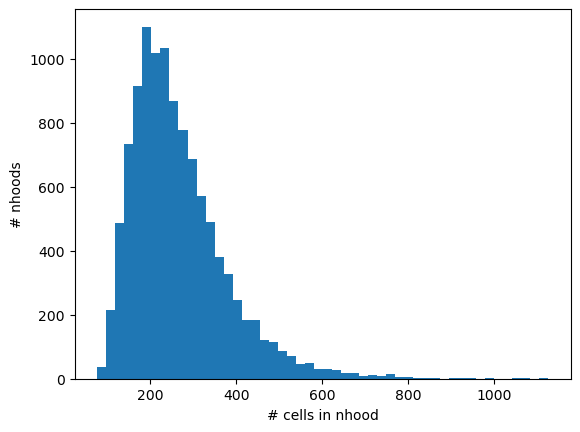

In [20]:
nhood_size = np.array(mdata_nk["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins=50)
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

Text(0, 0.5, '# nhoods')

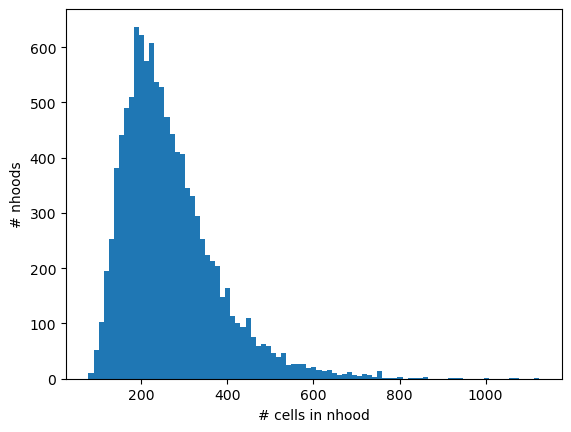

In [21]:
nhood_size = np.array(mdata_nk["rna"].obsm["nhoods"].sum(0)).ravel()
plt.hist(nhood_size, bins='auto')
plt.xlabel("# cells in nhood")
plt.ylabel("# nhoods")

In [22]:
# count cells in neighbourhood
mdata_nk= milo.count_nhoods(mdata_nk, sample_col="pica_id") 

In [23]:
mdata_nk

MuData object with n_obs × n_vars = 207458 × 38606
  2 modalities
    rna:	207458 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 10944
      var:	'index_cell', 'kth_distance'
      uns:	'sample_

In [24]:
mdata_nk["milo"]

AnnData object with n_obs × n_vars = 128 × 10944
    var: 'index_cell', 'kth_distance'
    uns: 'sample_col'

In [25]:
donor_meta_nk = (
    adata_age_nk.obs[["pica_id", "Age_years","Age", "Sex", "Batch", "Age_group"]]
    .drop_duplicates("pica_id")
    .set_index("pica_id")
)
donor_meta_nk = donor_meta_nk.loc[mdata_nk["milo"].obs_names]

In [26]:
mdata_nk["milo"].obs["Age_years"] = donor_meta_nk["Age_years"].values
mdata_nk["milo"].obs["Sex"] = donor_meta_nk["Sex"].values
mdata_nk["milo"].obs["Batch"] = donor_meta_nk["Batch"].values
mdata_nk["milo"].obs["Age"] = donor_meta_nk["Age"].values
mdata_nk["milo"].obs["Age_group"] = donor_meta_nk["Age_group"].values


In [27]:
mdata_nk["milo"].obs["Sex"] = mdata_nk["milo"].obs["Sex"].astype("category")
mdata_nk["milo"].obs["Age_years"] = mdata_nk["milo"].obs["Age_years"].astype("float")
mdata_nk["milo"].obs["Batch"] = mdata_nk["milo"].obs["Batch"].astype("category")
mdata_nk["milo"].obs["Age"] = mdata_nk["milo"].obs["Age"].astype("int")
mdata_nk["milo"].obs["Age_group"] = mdata_nk["milo"].obs["Age_group"].astype("category")


In [28]:
mdata_nk["milo"].obs["Age_years"].value_counts().sort_index()

Age_years
0.05     1
0.07     1
0.14     1
0.35     1
0.48     1
        ..
16.16    1
16.20    1
16.29    1
16.78    1
17.03    1
Name: count, Length: 122, dtype: int64

In [29]:
mdata_nk["milo"].obs["Sex"].value_counts().sort_index()

Sex
Female    53
Male      75
Name: count, dtype: int64

In [30]:
mdata_nk

MuData object with n_obs × n_vars = 207458 × 38606
  2 modalities
    rna:	207458 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 10944
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'


### DA testing with GLM

In [31]:
mdata_nk

MuData object with n_obs × n_vars = 207458 × 38606
  2 modalities
    rna:	207458 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'pica_cell_type_complete_01_gdT_corrected_colors', 'sequencing_batch_colors', 'umap', 'pool_id_colors', 'Sex_colors', 'nhood_neighbors_key'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 10944
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'


In [32]:
milo.da_nhoods(
    mdata_nk,
    design="~ Age_years * Sex + Batch",   # Age_group last = main effect of interest
    solver="pydeseq2"                  # use "edger" only if you set up rpy2+edgeR
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 21.15 seconds.

Fitting MAP dispersions...
... done in 2.63 seconds.

Fitting dispersions...
... done in 2.41 seconds.

Fitting MAP dispersions...
... done in 2.47 seconds.

Fitting dispersions...
... done in 2.47 seconds.

Fitting MAP dispersions...
... done in 2.47 seconds.

Fitting dispersions...
... done in 2.41 seconds.

Fitting MAP dispersions...
... done in 2.49 seconds.

Fitting dispersions...
... done in 2.46 seconds.

Fitting MAP dispersions...
... done in 2.44 seconds.

Fitting dispersions...
... done in 2.47 seconds.

Fitting MAP dispersions...
... done in 2.41 seconds.

Fitting dispersions...
... done in 2.40 seconds.

Fitting MAP dispersions...
... done in 2.48 seconds.

Fitting dispersions

Log2 fold change & Wald test p-value: Batch Batch07 vs Batch01
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0      7.449452       -5.026674  1.034025 -4.861271  0.000001  0.000121
1      1.102767       -3.505387  1.451683 -2.414705  0.015748       NaN
2      2.242293       -0.862309  1.210928 -0.712105  0.476400  0.846048
3      2.401335       -2.278788  1.103282 -2.065463  0.038879  0.265355
4      0.777873       -2.617997  1.799870 -1.454547  0.145795       NaN
...         ...             ...       ...       ...       ...       ...
10939  1.489440       -0.557229  0.854413 -0.652178  0.514287  0.866824
10940  3.096393       -0.828787  0.744104 -1.113806  0.265362  0.683145
10941  1.491281       -1.224669  0.696740 -1.757713  0.078796  0.389829
10942  1.194987       -1.632584  0.893588 -1.826998  0.067700       NaN
10943  1.148104       -1.550570  0.997372 -1.554655  0.120028       NaN

[10944 rows x 6 columns]


... done in 1.46 seconds.



In [33]:
mdata_nk["milo"].obs["pica_id"] = mdata_nk["milo"].obs.index

In [3]:
mdata_nk["milo"].obs["Age_group"] = pd.cut(
    mdata_nk["milo"].obs["Age_years"],
    bins=[0,3,6,10,14,18],
    labels=["0-3","4-6","7-10","11-14","15-18"],
    include_lowest=True
)

mdata_nk["milo"].obs["Age_group"] = pd.Categorical(
    mdata_nk["milo"].obs["Age_group"],
    categories=["0-3","4-6","7-10","11-14","15-18"],
    ordered=True
)

In [4]:
mdata_nk

MuData object with n_obs × n_vars = 207586 × 49550
  2 modalities
    rna:	207458 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'nhood_neighbors_key', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 10944
      obs:	'Sex', 'Age_years', 'Batch', 'pica_id', 'Age_gro

In [5]:
mdata_nk["milo"].obs

,Sex,Age_years,Batch,pica_id,Age_group
PICA0001,Male,2.09,Batch01,PICA0001,0-3
PICA0002,Male,15.09,Batch01,PICA0002,15-18
PICA0003,Male,0.83,Batch01,PICA0003,0-3
PICA0004,Male,1.46,Batch01,PICA0004,0-3
PICA0005,Male,9.30,Batch01,PICA0005,7-10
...,...,...,...,...,...
PICA0164,Male,2.15,Batch07,PICA0164,0-3
PICA0166,Male,0.62,Batch07,PICA0166,0-3
PICA0168,Male,16.20,Batch07,PICA0168,15-18
PICA0169,Male,2.72,Batch07,PICA0169,0-3


In [36]:
mdata_nk["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.366576,7.449452,-5.026674,0.000001,0.000121,0.000190
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.884105,1.102767,-3.505387,0.015748,NaN,0.198690
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.503809,2.242293,-0.862309,0.476400,0.846048,0.906322
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.358956,2.401335,-2.278788,0.038879,0.265355,0.337094
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,4.025349,0.777873,-2.617997,0.145795,NaN,0.627569
...,...,...,...,...,...,...,...
10939,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.502956,1.489440,-0.557229,0.514287,0.866824,0.921214
10940,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.210480,3.096393,-0.828787,0.265362,0.683145,0.768875
10941,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,4.441019,1.491281,-1.224669,0.078796,0.389829,0.478526
10942,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.469326,1.194987,-1.632584,0.067700,NaN,0.445265


In [37]:
mdata_nk.write_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_nhood.h5mu")

In [2]:
mdata_nk=mu.read_h5mu("/scratch/user/s4575250/BIOX7018_thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_nhood.h5mu")

In [39]:
mdata_nk["milo"].var.to_csv("/scratch/user/s4575250/BIOX7018_thesis/Results/PICA_Batch001-Batch007/03_milo/nk_milo_results.csv")

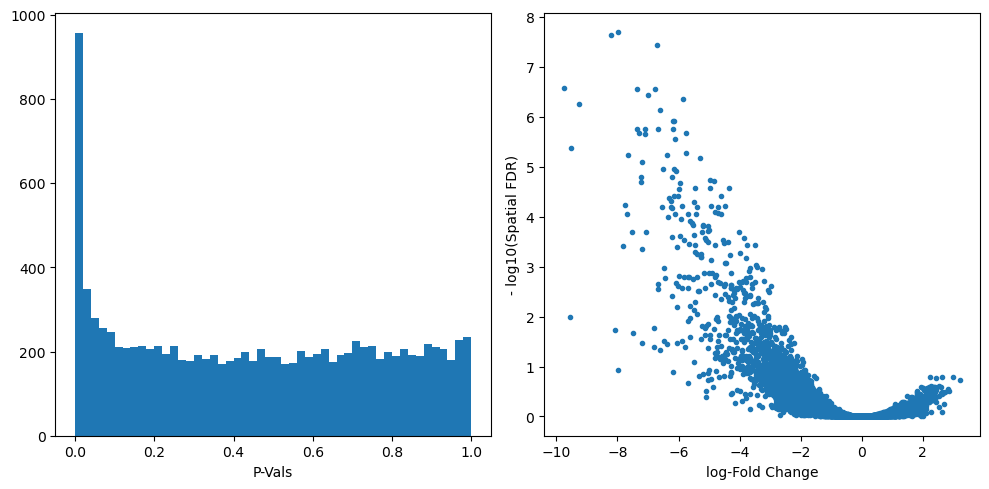

In [40]:
# QC
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_nk["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_nk["milo"].var.logFC, -np.log10(mdata_nk["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

### Visualize embedding

In [6]:
milo.build_nhood_graph(mdata_nk)

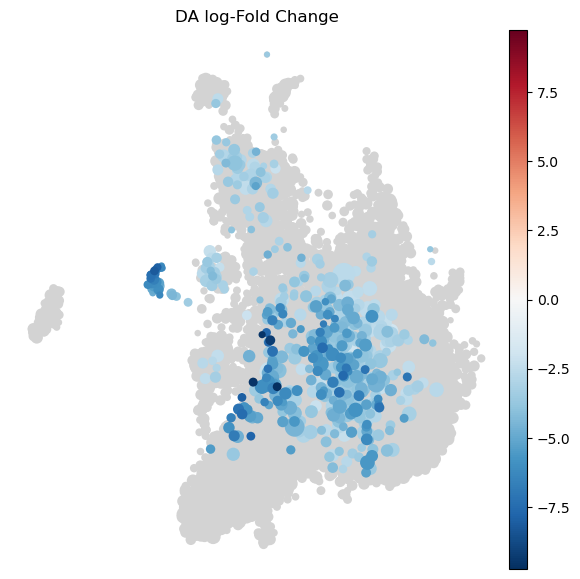

In [7]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_nk,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot, change if needed
)

### Visualize by cell type

In [8]:
milo.annotate_nhoods(mdata_nk, anno_col="pica_cell_type_complete_01_gdT_corrected")


Text(0.5, 0, 'celltype fraction')

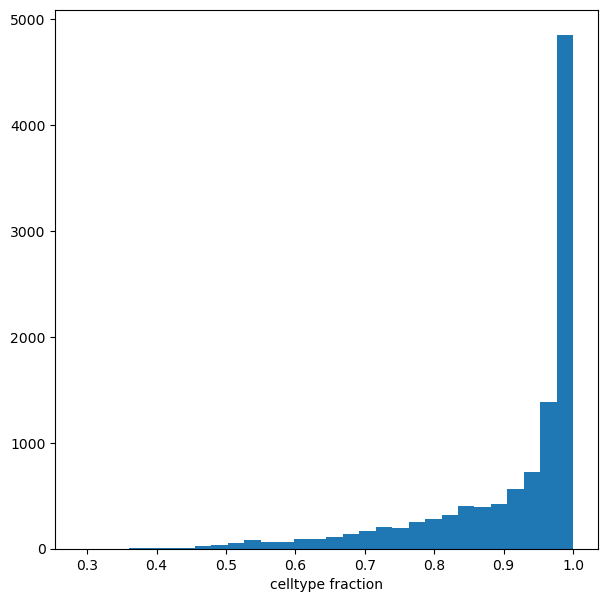

In [9]:
plt.hist(mdata_nk["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [10]:
mdata_nk["milo"].var["nhood_annotation"] = mdata_nk["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_nk["milo"].var.loc[mdata_nk["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pertpy/tools/_milo.py:1014: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nhood_adata.obs[[anno_col, "logFC"]].groupby(anno_col).median().sort_values("logFC", ascending=True).index
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pertpy/tools/_milo.py:1031: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pertpy/tools/_milo.py:1043: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


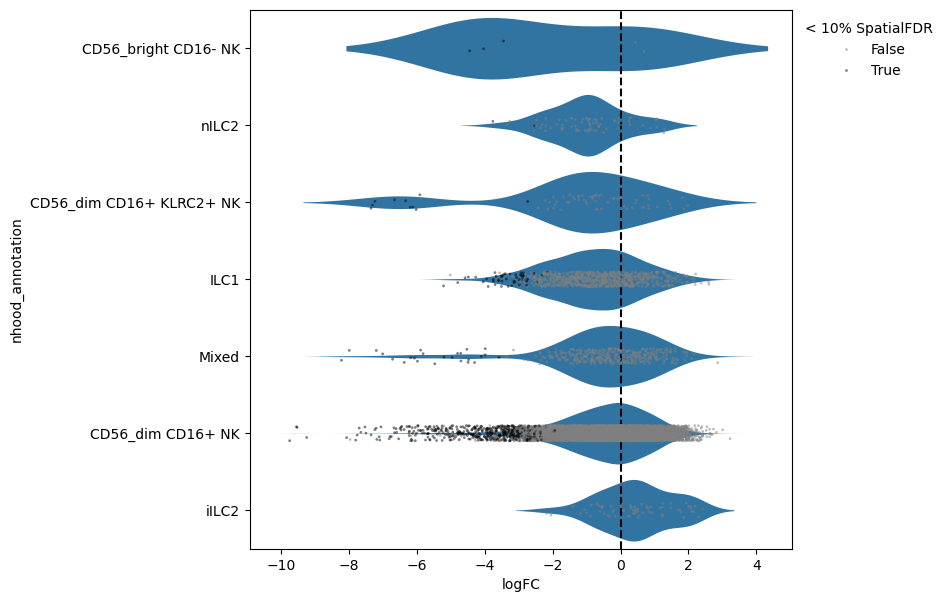

In [11]:
milo.plot_da_beeswarm(mdata_nk, alpha=0.1)

In [12]:
sig_nhoods_nk = mdata_nk["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods_nk.sort_values("logFC", ascending=False).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac
10921,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.154779,3.253028,-1.936046,0.003523,0.056139,0.080427,476.0,CD56_dim CD16+ NK,0.993697
5063,20250814_WGS_20250814_sc_PICA0147-PICA0173_Poo...,3.244377,4.022349,-1.941071,0.004471,0.066951,0.095080,608.0,CD56_dim CD16+ NK,0.995066
10656,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.296436,2.594559,-1.963754,0.002851,0.049523,0.071153,367.0,CD56_dim CD16+ NK,0.967302
2674,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.258898,2.743123,-2.026831,0.004637,0.068077,0.096825,401.0,CD56_dim CD16+ NK,0.942643
5831,20250324_WGS_20250324_sc_PICA0098-PICA0118_Poo...,3.833435,1.225013,-2.103163,0.002334,NaN,0.062479,201.0,CD56_dim CD16+ NK,0.840796


<Figure size 700x700 with 0 Axes>

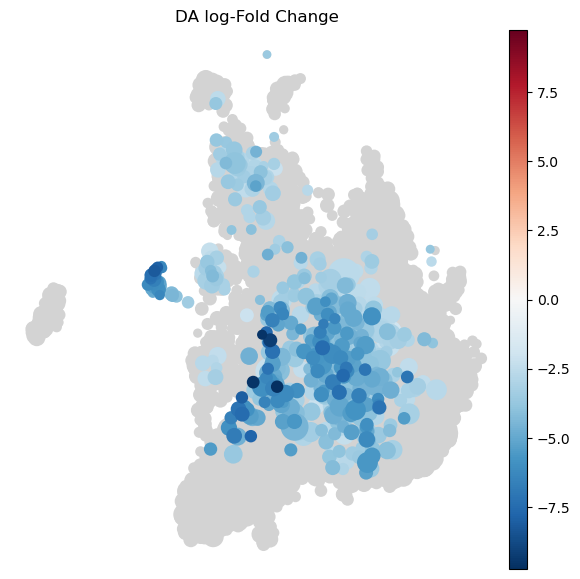

In [13]:
milo.build_nhood_graph(mdata_nk)

plt.figure(figsize=(7, 7))
milo.plot_nhood_graph(
    mdata_nk,
    alpha=0.1,        # SpatialFDR threshold
    min_size=2
)

<Axes: xlabel='logFC', ylabel='kth_distance'>

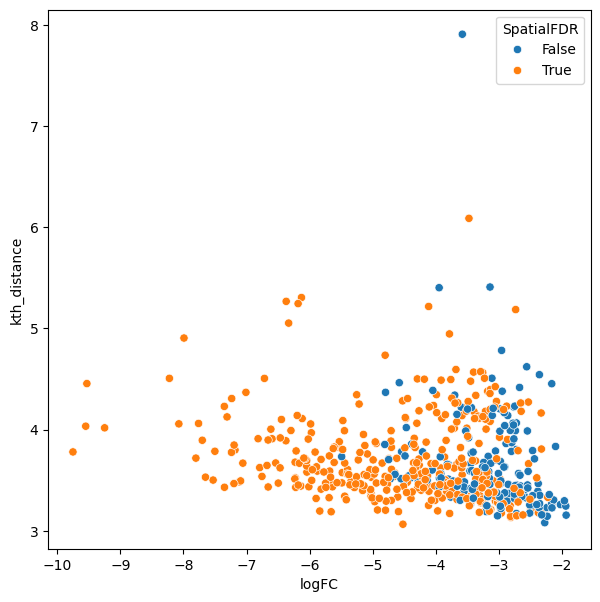

In [14]:
sns.scatterplot(
    data=sig_nhoods_nk,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods_nk["SpatialFDR"] < 0.05)
)

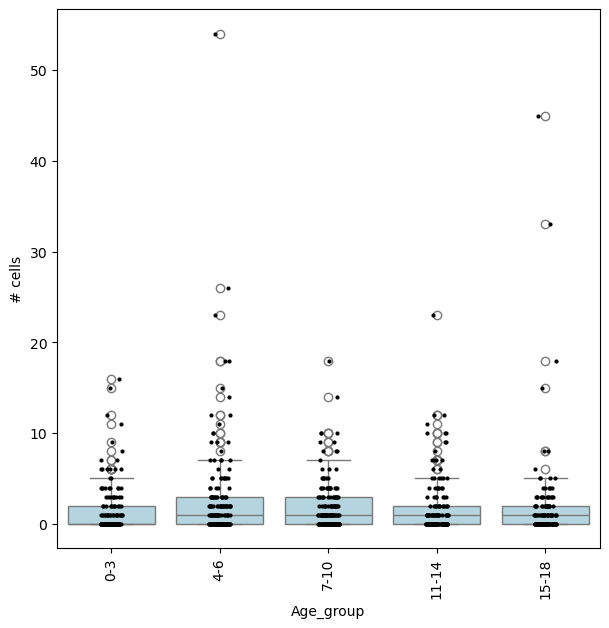

In [15]:
milo.plot_nhood_counts_by_cond(
    mdata_nk,
    test_var="Age_group",
    subset_nhoods=sig_nhoods_nk.index[:6],
    log_counts=False
)

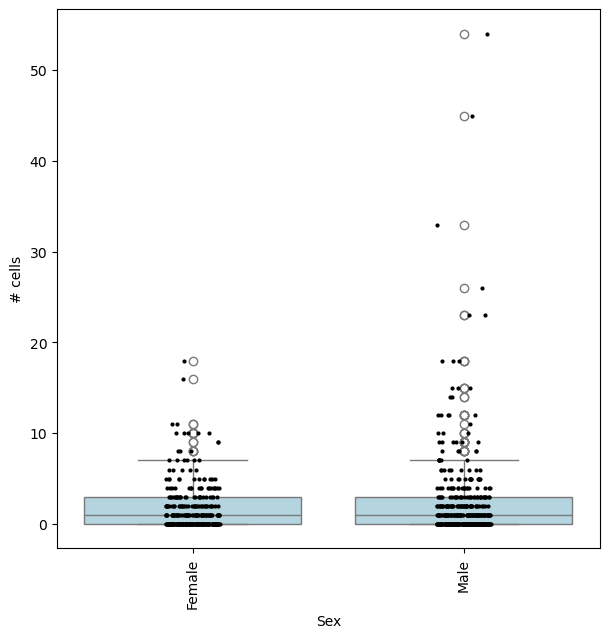

In [16]:
milo.plot_nhood_counts_by_cond(
    mdata_nk,
    test_var="Sex",
    subset_nhoods=sig_nhoods_nk.index[:6],
    log_counts=False
)

In [17]:
pl_nhoods_nk = (
    mdata_nk["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

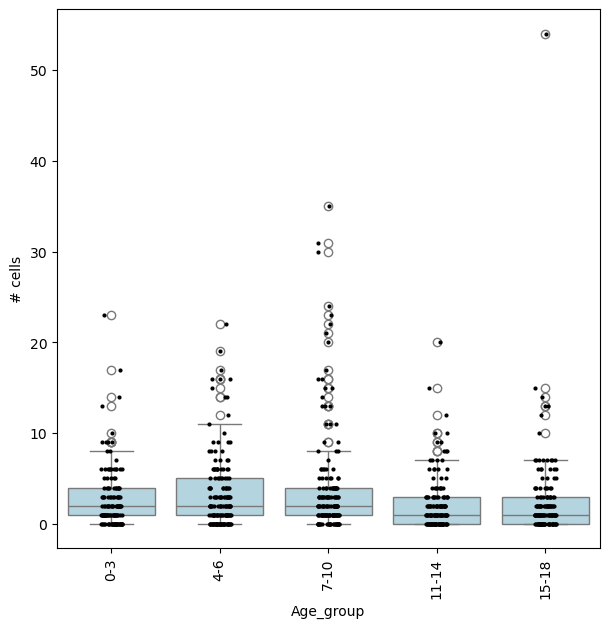

In [18]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_nk, test_var="Age_group", subset_nhoods=pl_nhoods_nk, log_counts=False)

In [19]:
pl_nhoods_neg_nk = (
    mdata_nk["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=True)
    .index[:6]
)

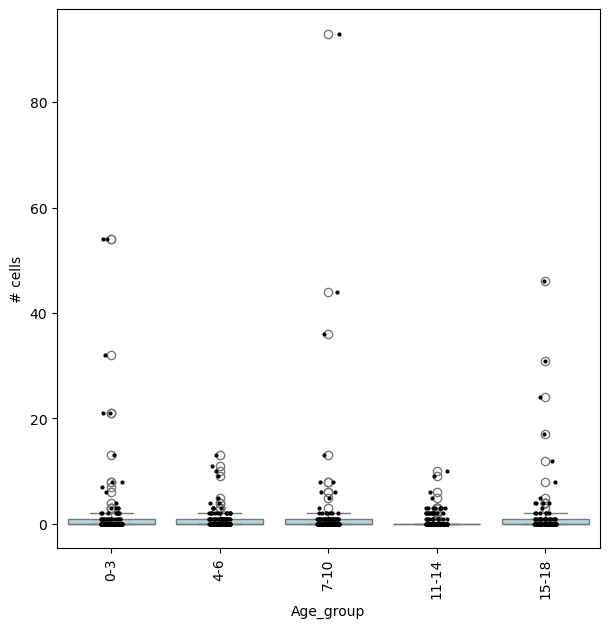

In [20]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_nk, test_var="Age_group", subset_nhoods=pl_nhoods_neg_nk, log_counts=False)

In [21]:
mdata_nk

MuData object with n_obs × n_vars = 207586 × 49550
  2 modalities
    rna:	207458 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age_in_years_int', 'Age_group', '_scvi_batch', '_scvi_labels', 'Batch', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'nhood_neighbors_key', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 10944
      obs:	'Sex', 'Age_years', 'Batch', 'pica_id', 'Age_gro